# 02. Kinetics: what happens when the rising part of the curve was never sampled

The contact-time series was measured at 30, 60, 90, 120 and 150 min. The
pseudo-second-order model is the default choice in the adsorption literature,
and it is almost always reported with a high R2 from its linearised form.

This notebook tests it properly against four alternatives, including the
possibility that nothing is happening at all over the sampled window.

In [1]:
import sys
sys.path.insert(0, "src")

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

from adsorption import (concentration, uptake, plateau, pfo, pso, elovich,
                        intraparticle, fit_model, fit_plateau)

raw = pd.read_csv("data/aas_readings.csv")
CONTROL = {m: float(concentration(
    raw.loc[(raw.series == "control") & (raw.metal == m), "reading_mg_L"].iloc[0],
    raw.loc[(raw.series == "control") & (raw.metal == m), "dilution_factor"].iloc[0]))
    for m in ["Mn", "Zn"]}

USED = ["time_30", "time_60", "time_90", "time_120_dirt",
        "time_120_sample", "time_150"]
kin = raw[(raw.series == "time") & (raw.label.isin(USED))].copy()
kin["Ce"] = concentration(kin["reading_mg_L"], kin["dilution_factor"])
kin["qt"] = uptake([CONTROL[m] for m in kin.metal], kin["Ce"],
                   kin["volume_L"], kin["mass_g"])

series = {m: kin[kin.metal == m].sort_values("time_min") for m in ["Mn", "Zn"]}
for m, d in series.items():
    print(f"{m}(II):  t = {d.time_min.tolist()}")
    print(f"        qt = {np.round(d.qt.to_numpy(), 3).tolist()} mg/g")
print()
print("Note the duplicate 120-min readings in the lab report. The reading")
print("consistent with the other reference-condition batches is used; the")
print("alternative is kept in the data file and discussed at the end.")

Mn(II):  t = [30.0, 60.0, 90.0, 120.0, 150.0]
        qt = [0.25, 0.192, 0.292, 1.475, 0.458] mg/g
Zn(II):  t = [30.0, 60.0, 90.0, 120.0, 150.0]
        qt = [2.088, 1.838, 3.196, 1.983, 2.846] mg/g

Note the duplicate 120-min readings in the lab report. The reading
consistent with the other reference-condition batches is used; the
alternative is kept in the data file and discussed at the end.


## Five candidate descriptions

Four of these are the standard kinetic models. The fifth, the plateau, has one
parameter and no time dependence at all: it says uptake was already constant
before the first measurement. It is included because the data might simply not
contain a rising section, and a model that is never offered can never be
chosen.

Models with different parameter counts are compared with the small-sample
Akaike information criterion. Lower is better; a gap of more than about 2 units
is meaningful.

In [2]:
def fit_kinetics(t, q):
    t = np.asarray(t, float)
    q = np.asarray(q, float)
    ipd_guess = linregress(np.sqrt(t), q)
    out = {}
    out["Plateau (1 param)"] = fit_plateau(q)
    out["Pseudo-first-order"] = fit_model(
        pfo, t, q, p0=[q.max(), 0.01], bounds=([0, 1e-6], [np.inf, np.inf]))
    out["Pseudo-second-order"] = fit_model(
        pso, t, q, p0=[q.max(), 0.001], bounds=([0, 1e-9], [np.inf, np.inf]))
    out["Elovich"] = fit_model(
        elovich, t, q, p0=[0.05, 1.0], bounds=([1e-9, 1e-9], [np.inf, np.inf]))
    out["Intraparticle diffusion"] = fit_model(
        intraparticle, t, q, p0=[ipd_guess.slope, ipd_guess.intercept])
    return out

fits = {}
for metal, d in series.items():
    fits[metal] = fit_kinetics(d.time_min, d.qt)
    best = min(v["aicc"] for v in fits[metal].values())
    rows = []
    for name, r in fits[metal].items():
        rows.append({
            "model": name,
            "params": np.array2string(r["params"], precision=4),
            "R2": round(r["r2"], 2),
            "RMSE": round(r["rmse"], 3),
            "AICc": round(r["aicc"], 1),
            "dAICc": round(r["aicc"] - best, 1)})
    print(f"=== {metal}(II)  (n = {len(d)}) ===")
    print(pd.DataFrame(rows).to_string(index=False))
    print()

=== Mn(II)  (n = 5) ===
                  model                  params   R2  RMSE  AICc  dAICc
      Plateau (1 param)                [0.5333] 0.00 0.479  -4.0    0.0
     Pseudo-first-order         [1.752  0.0043] 0.26 0.412   1.1    5.2
    Pseudo-second-order [3.4312e+00 6.3083e-04] 0.26 0.412   1.1    5.2
                Elovich         [0.0073 0.5984] 0.26 0.413   1.1    5.2
Intraparticle diffusion       [ 0.1022 -0.4056] 0.26 0.412   1.1    5.2

=== Zn(II)  (n = 5) ===
                  model          params   R2  RMSE  AICc  dAICc
      Plateau (1 param)          [2.39] 0.00 0.533  -3.0    0.0
     Pseudo-first-order [2.564  0.0452] 0.15 0.491   2.9    5.8
    Pseudo-second-order [2.8589 0.0254] 0.18 0.481   2.7    5.6
                Elovich [1.6129 2.39  ] 0.20 0.477   2.6    5.6
Intraparticle diffusion [0.0998 1.4736] 0.20 0.477   2.6    5.6



The plateau wins for both metals by about 5 AICc units, and the four
time-dependent models are indistinguishable from each other (R2 between 0.15
and 0.26). They agree with one another because there is no rising section for
them to disagree about.

A direct test says the same thing.

In [3]:
for metal, d in series.items():
    lr = linregress(d.time_min, d.qt)
    print(f"{metal}(II): linear trend of qt with time, slope = {lr.slope:+.5f} "
          f"mg/g/min, p = {lr.pvalue:.2f}")
print()
print("Neither metal shows a significant change in uptake between 30 and")
print("150 min. The system had already plateaued by the first measured point.")
print("No rate constant can be recovered from data like this, and the PFO/PSO")
print("rate constants printed above are fitted to noise.")

Mn(II): linear trend of qt with time, slope = +0.00567 mg/g/min, p = 0.39
Zn(II): linear trend of qt with time, slope = +0.00554 mg/g/min, p = 0.46

Neither metal shows a significant change in uptake between 30 and
150 min. The system had already plateaued by the first measured point.
No rate constant can be recovered from data like this, and the PFO/PSO
rate constants printed above are fitted to noise.


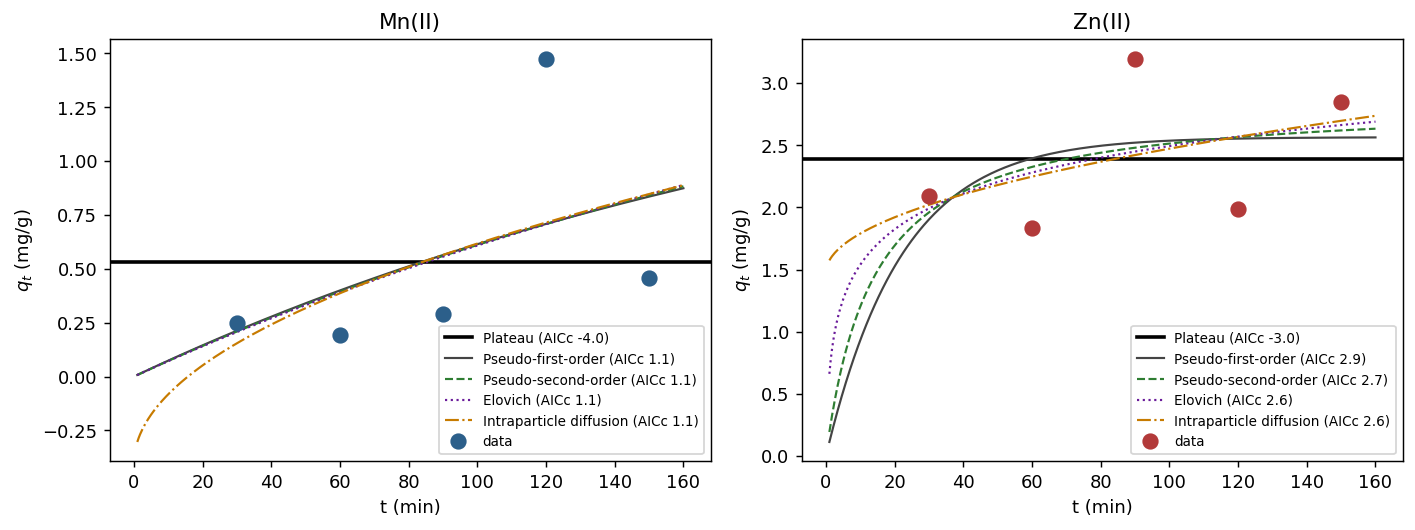

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
grid = np.linspace(1, 160, 400)
funcs = {"Pseudo-first-order": pfo, "Pseudo-second-order": pso,
         "Elovich": elovich, "Intraparticle diffusion": intraparticle}
styles = {"Pseudo-first-order": ("-", "#444444"),
          "Pseudo-second-order": ("--", "#2e7d32"),
          "Elovich": (":", "#6a1b9a"),
          "Intraparticle diffusion": ("-.", "#c77b00")}

for ax, (metal, d) in zip(axes, series.items()):
    colour = "#2c5f8a" if metal == "Mn" else "#b23a3a"
    r = fits[metal]
    ax.axhline(r["Plateau (1 param)"]["params"][0], color="#000000", lw=2,
               label=f"Plateau (AICc {r['Plateau (1 param)']['aicc']:.1f})")
    for name, func in funcs.items():
        if not r[name]["converged"]:
            continue
        ls, c = styles[name]
        ax.plot(grid, func(grid, *r[name]["params"]), ls, color=c, lw=1.2,
                label=f"{name} (AICc {r[name]['aicc']:.1f})")
    ax.plot(d.time_min, d.qt, "o", color=colour, ms=8, label="data")
    ax.set_xlabel("t (min)")
    ax.set_ylabel("$q_t$ (mg/g)")
    ax.set_title(f"{metal}(II)")
    ax.legend(fontsize=7.5, loc="lower right")

fig.tight_layout()

## The linearised pseudo-second-order plot

This is the plot that appears in most adsorption papers: `t/qt` against `t`.
For Zn(II) it gives R2 = 0.78, which would normally be reported as support for
the model.

It is not support for anything. Time appears on both axes, so the plot is
largely plotting `t` against itself.

Linearised PSO R2: {'Mn': np.float64(0.06), 'Zn': np.float64(0.78)}
Non-linear PSO R2: {'Mn': 0.26, 'Zn': 0.18}


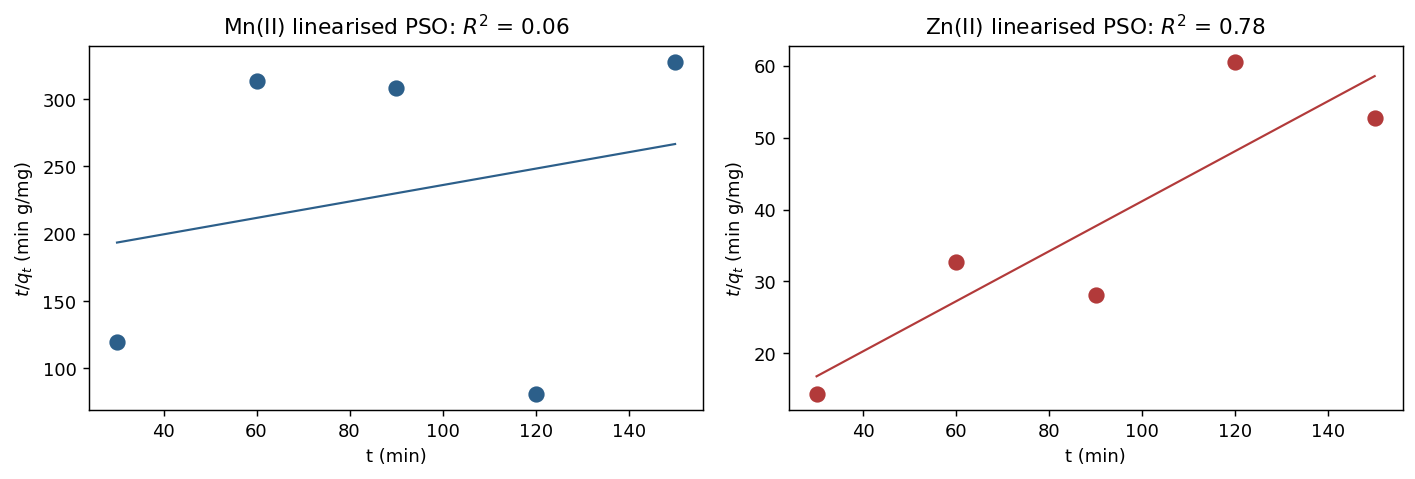

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
lin_r2 = {}
for ax, (metal, d) in zip(axes, series.items()):
    t = d.time_min.to_numpy(float)
    y = t / d.qt.to_numpy(float)
    lr = linregress(t, y)
    lin_r2[metal] = lr.rvalue ** 2
    colour = "#2c5f8a" if metal == "Mn" else "#b23a3a"
    ax.plot(t, y, "o", color=colour, ms=8)
    ax.plot(t, lr.intercept + lr.slope * t, "-", color=colour, lw=1.2)
    ax.set_xlabel("t (min)")
    ax.set_ylabel("$t/q_t$ (min g/mg)")
    ax.set_title(f"{metal}(II) linearised PSO: $R^2$ = {lr.rvalue**2:.2f}")
fig.tight_layout()

print("Linearised PSO R2:", {k: round(v, 2) for k, v in lin_r2.items()})
print("Non-linear PSO R2:",
      {m: round(fits[m]['Pseudo-second-order']['r2'], 2) for m in fits})

## A permutation test on the linearised plot

If the R2 of 0.78 reflects real agreement with the pseudo-second-order model,
then destroying the relationship between uptake and time should destroy it.

With five observations there are only 120 possible assignments of the measured
`qt` values to the five times, so every one of them can be enumerated rather
than sampled.

In [6]:
for metal, d in series.items():
    t = d.time_min.to_numpy(float)
    q = d.qt.to_numpy(float)
    r2s = []
    for perm in itertools.permutations(range(len(q))):
        shuffled = q[list(perm)]
        lr = linregress(t, t / shuffled)
        r2s.append(lr.rvalue ** 2)
    r2s = np.array(r2s)
    observed = lin_r2[metal]
    share = (r2s >= observed).mean()
    print(f"{metal}(II):  observed linearised R2 = {observed:.2f}")
    print(f"          median R2 over all {len(r2s)} permutations = "
          f"{np.median(r2s):.2f}")
    print(f"          permutations reaching R2 >= observed: {share:.0%}")
    print()

print("For Zn(II) the median R2 of randomly shuffled data is HIGHER than the")
print("R2 of the real data. The linearised plot cannot distinguish the")
print("measurements from noise, so it is not evidence for the model, and the")
print("chemisorption mechanism usually inferred from a good PSO fit is not")
print("supported by this experiment.")

Mn(II):  observed linearised R2 = 0.06
          median R2 over all 120 permutations = 0.49
          permutations reaching R2 >= observed: 87%

Zn(II):  observed linearised R2 = 0.78
          median R2 over all 120 permutations = 0.83
          permutations reaching R2 >= observed: 79%

For Zn(II) the median R2 of randomly shuffled data is HIGHER than the
R2 of the real data. The linearised plot cannot distinguish the
measurements from noise, so it is not evidence for the model, and the
chemisorption mechanism usually inferred from a good PSO fit is not
supported by this experiment.


In [7]:
# Sensitivity: does the choice between the duplicate 120-min readings matter?
ALT = {"Mn": "time_120_clea", "Zn": "time_120_std"}
for metal in ["Mn", "Zn"]:
    d = series[metal].copy()
    alt_row = raw[(raw.metal == metal) & (raw.label == ALT[metal])].iloc[0]
    alt_q = float(uptake(CONTROL[metal],
                         concentration(alt_row.reading_mg_L, alt_row.dilution_factor),
                         alt_row.volume_L, alt_row.mass_g))
    q_alt = d.qt.to_numpy(float).copy()
    q_alt[d.time_min.to_numpy() == 120] = alt_q
    alt_fits = fit_kinetics(d.time_min, q_alt)
    best_name = min(alt_fits, key=lambda k: alt_fits[k]["aicc"])
    print(f"{metal}(II) with the alternative 120-min reading "
          f"(qt = {alt_q:.2f} mg/g): best model = {best_name}")
print()
print("The plateau is still preferred either way, so the conclusion does not")
print("depend on which of the two undocumented 120-min readings is used.")

Mn(II) with the alternative 120-min reading (qt = -0.58 mg/g): best model = Plateau (1 param)
Zn(II) with the alternative 120-min reading (qt = 0.81 mg/g): best model = Plateau (1 param)

The plateau is still preferred either way, so the conclusion does not
depend on which of the two undocumented 120-min readings is used.


## Conclusions

- The constant-uptake plateau is the best-supported description for both
  metals, by roughly 5 AICc units over any two-parameter kinetic model.
- Uptake had already levelled off by the first measurement at 30 min. The
  experiment cannot establish an equilibration time below 30 min, and it cannot
  produce a reliable rate constant.
- The linearised pseudo-second-order R2 is an artefact of `t` appearing on both
  axes. Shuffled data scores higher.
- The conclusion survives the ambiguity in the duplicate 120-min readings.

The practical fix is in the thesis recommendations: sample at 2, 5, 10 and 20
min so that the rising part of the curve is actually measured. A kinetic model
cannot be fitted to a region that was never observed.